# Análise Comparativa de Desempenho: Ubuntu 26.04.1 vs Kali Linux 2026.2

**Grupo: BAGÉ SYSTEMS**
Eduardo Munhoz Umpierre, Brian Rodrigues, Pedro Carrion Munhoz

Este notebook reproduz, em forma de gráficos, os dados coletados no relatório comparativo entre **Ubuntu 26.04.1** e **Kali Linux 2026.2**, executados em máquinas virtuais equivalentes no VMware Workstation, usando `sysbench` (CPU e memória), `htop` (consumo em estado ocioso) e o comando `time` (aplicações e compilação/execução em C).

> Os dados abaixo foram inseridos manualmente a partir das medições registradas no relatório (execução única por cenário, análise descritiva).

## 1. Configuração inicial

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 110
distros = ["Ubuntu 26.04.1", "Kali Linux 2026.2"]
cores = ["#E95420", "#557C94"]  # laranja Ubuntu, azul Kali

## 2. Dados coletados

Tabela de hardware das VMs: 8 GB RAM, 1 processador virtual (4 núcleos), 20 GB de SSD para ambas as distribuições.

In [2]:
dados = {
    "disco_gb": [8.6, 15.6],
    "ram_idle_gb": [1.04, 0.762],
    "cpu_eventos_s": [1044.93, 1064.46],
    "mem_taxa_mibs": [6371.62, 6487.28],
}
dados

{'disco_gb': [8.6, 15.6],
 'ram_idle_gb': [1.04, 0.762],
 'cpu_eventos_s': [1044.93, 1064.46],
 'mem_taxa_mibs': [6371.62, 6487.28]}

## 3. Espaço em disco e RAM ociosa

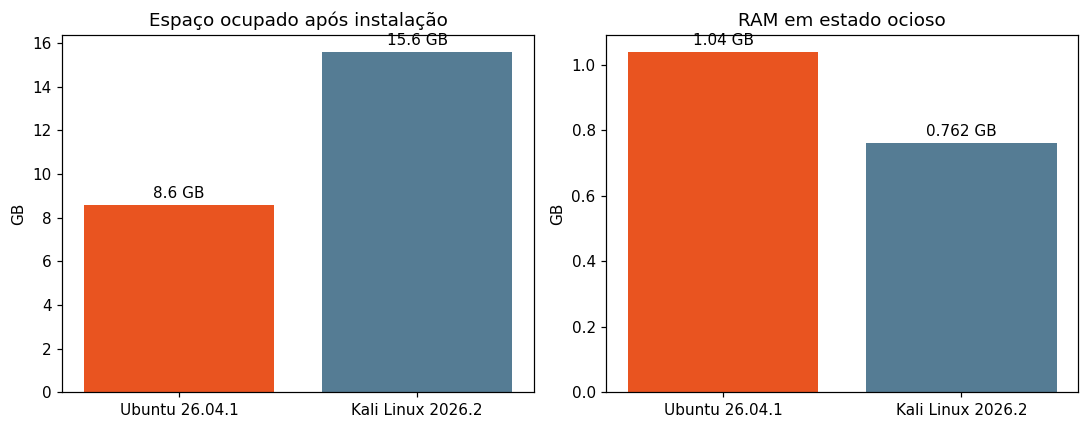

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(distros, dados["disco_gb"], color=cores)
axes[0].set_title("Espaço ocupado após instalação")
axes[0].set_ylabel("GB")
for i, v in enumerate(dados["disco_gb"]):
    axes[0].text(i, v + 0.3, f"{v} GB", ha="center")

axes[1].bar(distros, dados["ram_idle_gb"], color=cores)
axes[1].set_title("RAM em estado ocioso")
axes[1].set_ylabel("GB")
for i, v in enumerate(dados["ram_idle_gb"]):
    axes[1].text(i, v + 0.02, f"{v} GB", ha="center")

plt.tight_layout()
plt.show()

**Observação:** o Kali ocupou cerca de **81,4% a mais** de espaço em disco que o Ubuntu, enquanto consumiu menos RAM em estado ocioso — possivelmente influenciado pelo uso do XFCE (mais leve que o GNOME do Ubuntu).

## 4. Benchmark de CPU (sysbench — 20 mil números primos)

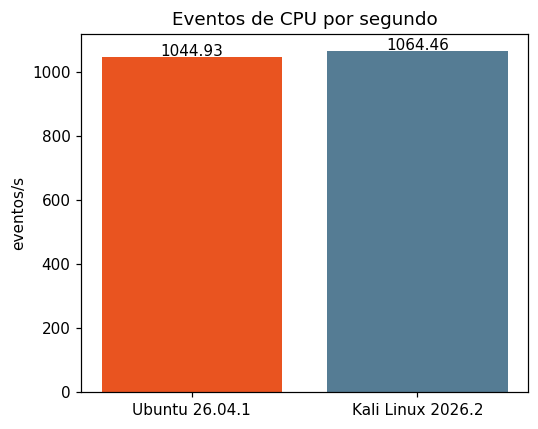

Diferença a favor do Kali: 1.87%


In [4]:
plt.figure(figsize=(5, 4))
plt.bar(distros, dados["cpu_eventos_s"], color=cores)
plt.title("Eventos de CPU por segundo")
plt.ylabel("eventos/s")
for i, v in enumerate(dados["cpu_eventos_s"]):
    plt.text(i, v + 5, f"{v}", ha="center")
plt.tight_layout()
plt.show()

dif_cpu = (dados["cpu_eventos_s"][1] - dados["cpu_eventos_s"][0]) / dados["cpu_eventos_s"][0] * 100
print(f"Diferença a favor do Kali: {dif_cpu:.2f}%")

## 5. Benchmark de memória (sysbench — blocos de 1 KiB até 100 GiB)

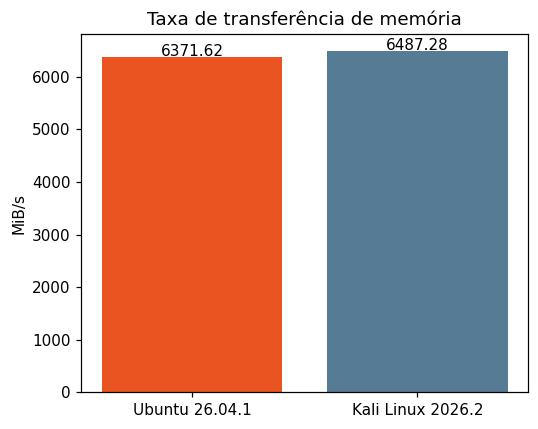

Diferença a favor do Kali: 1.82%


In [5]:
plt.figure(figsize=(5, 4))
plt.bar(distros, dados["mem_taxa_mibs"], color=cores)
plt.title("Taxa de transferência de memória")
plt.ylabel("MiB/s")
for i, v in enumerate(dados["mem_taxa_mibs"]):
    plt.text(i, v + 20, f"{v}", ha="center")
plt.tight_layout()
plt.show()

dif_mem = (dados["mem_taxa_mibs"][1] - dados["mem_taxa_mibs"][0]) / dados["mem_taxa_mibs"][0] * 100
print(f"Diferença a favor do Kali: {dif_mem:.2f}%")

## 6. Testes de aplicações multiplataforma (VS Code, Nmap, Firefox)

Complementando os benchmarks sintéticos, foram medidos o tempo de inicialização/execução (comando `time`) e o consumo de CPU/RAM (via `htop`) do **Visual Studio Code** e do **Firefox** nas duas distribuições, além do tempo de execução do **Nmap** contra o host local (`nmap 127.0.0.1`).

> Execução única por cenário — os tempos do VS Code, em especial, podem ter sido influenciados pelo estado prévio do editor (arquitetura cliente-servidor do comando `code`).

In [6]:
apps_tempo = {
    "vscode_real_s": [1.351, 0.09],
    "nmap_real_s": [0.068, 0.13],
    "firefox_real_s": [3.597, 3.31],
}
apps_cpu_ram = {
    "vscode_ram_pct": [2.7, 3.4],
    "firefox_ram_pct": [6.6, 4.1],
}
apps_tempo, apps_cpu_ram

({'vscode_real_s': [1.351, 0.09],
  'nmap_real_s': [0.068, 0.13],
  'firefox_real_s': [3.597, 3.31]},
 {'vscode_ram_pct': [2.7, 3.4], 'firefox_ram_pct': [6.6, 4.1]})

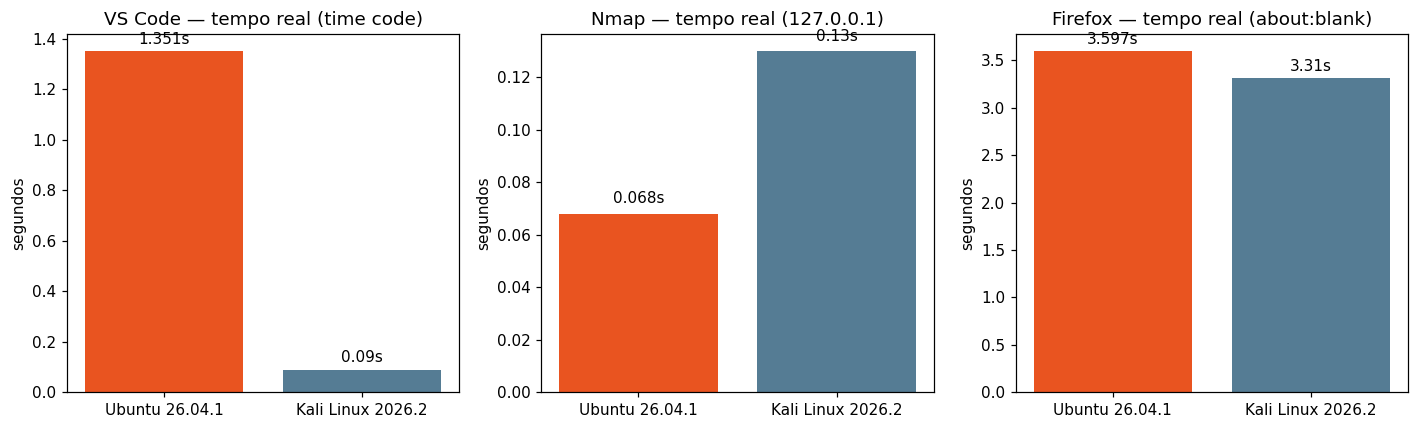

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(distros, apps_tempo["vscode_real_s"], color=cores)
axes[0].set_title("VS Code — tempo real (time code)")
axes[0].set_ylabel("segundos")
for i, v in enumerate(apps_tempo["vscode_real_s"]):
    axes[0].text(i, v + 0.03, f"{v}s", ha="center")

axes[1].bar(distros, apps_tempo["nmap_real_s"], color=cores)
axes[1].set_title("Nmap — tempo real (127.0.0.1)")
axes[1].set_ylabel("segundos")
for i, v in enumerate(apps_tempo["nmap_real_s"]):
    axes[1].text(i, v + 0.004, f"{v}s", ha="center")

axes[2].bar(distros, apps_tempo["firefox_real_s"], color=cores)
axes[2].set_title("Firefox — tempo real (about:blank)")
axes[2].set_ylabel("segundos")
for i, v in enumerate(apps_tempo["firefox_real_s"]):
    axes[2].text(i, v + 0.08, f"{v}s", ha="center")

plt.tight_layout()
plt.show()

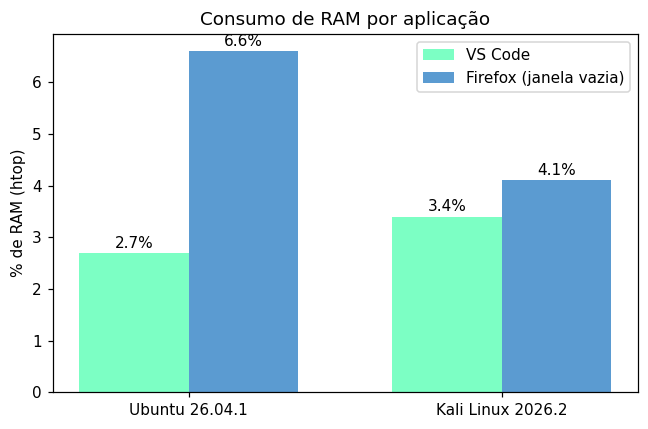

In [8]:
x = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, apps_cpu_ram["vscode_ram_pct"], width, label="VS Code", color="#7CFFC4")
ax.bar(x + width/2, apps_cpu_ram["firefox_ram_pct"], width, label="Firefox (janela vazia)", color="#5B9BD1")
ax.set_xticks(x)
ax.set_xticklabels(distros)
ax.set_ylabel("% de RAM (htop)")
ax.set_title("Consumo de RAM por aplicação")
ax.legend()
for i, v in enumerate(apps_cpu_ram["vscode_ram_pct"]):
    ax.text(i - width/2, v + 0.1, f"{v}%", ha="center")
for i, v in enumerate(apps_cpu_ram["firefox_ram_pct"]):
    ax.text(i + width/2, v + 0.1, f"{v}%", ha="center")
plt.tight_layout()
plt.show()

**Observações:**
- O tempo de execução do **Nmap** foi próximo entre as distribuições (diferença de décimos de segundo, pouco significativa para uma varredura tão curta).
- O tempo do **VS Code** variou bastante (1,351 s no Ubuntu vs 0,09 s no Kali) — resultado a ser interpretado com cautela, já que o comando `code` pode apenas reconectar a um processo já em execução.
- O consumo de CPU do VS Code foi idêntico nas duas distros (0,0% a 0,7%). No Firefox, o pico de CPU foi levemente maior no Kali (até 1,3% vs até 0,7% no Ubuntu).
- O **VLC Media Player** e o **Snap** ainda não possuem dados quantitativos registrados nesta versão do relatório.

## 7. Teste de desempenho com programa em C

Programa em C compilado com o GCC e cronometrado com `time` nas duas distribuições. O programa percorre o intervalo de 500 a 1500 e imprime os valores que, divididos por 7, deixam resto igual a 3.

```c
#include <stdio.h>
int main()
{
    printf("Numeros entre 500 e 1500 que divididos por 7 deixam resto igual a 3:");
    for(int i=500;i<=1500;i++){
        if(i%7==3){
            printf("\n%d", i);
        }
    }
    return 0;
}
```

In [9]:
c_bench = {
    "compilacao_s": [0.048, 0.11],
    "execucao_s": [0.003, 0.00],
}
c_bench

{'compilacao_s': [0.048, 0.11], 'execucao_s': [0.003, 0.0]}

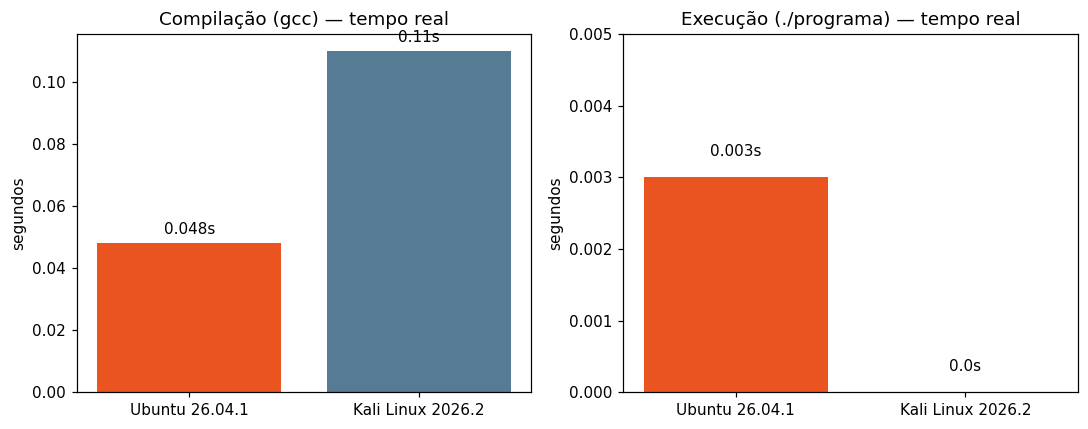

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(distros, c_bench["compilacao_s"], color=cores)
axes[0].set_title("Compilação (gcc) — tempo real")
axes[0].set_ylabel("segundos")
for i, v in enumerate(c_bench["compilacao_s"]):
    axes[0].text(i, v + 0.003, f"{v}s", ha="center")

axes[1].bar(distros, c_bench["execucao_s"], color=cores)
axes[1].set_title("Execução (./programa) — tempo real")
axes[1].set_ylabel("segundos")
axes[1].set_ylim(0, 0.005)
for i, v in enumerate(c_bench["execucao_s"]):
    axes[1].text(i, v + 0.0003, f"{v}s", ha="center")

plt.tight_layout()
plt.show()

**Observação:** na compilação, o Ubuntu foi mais rápido nesta execução (0,048 s vs 0,11 s no Kali). Na execução do binário já compilado, ambos os tempos foram da ordem de poucos milissegundos — o programa é simples (um único laço com uma operação de módulo), então o tempo total é dominado pela sobrecarga de carregamento do processo pelo sistema operacional, não pela complexidade do algoritmo.

## 8. Conclusão

- O **Kali Linux** apresentou desempenho ligeiramente superior em CPU (~1,87%) e memória (~1,82%), além de menor consumo de RAM ociosa — mas exigiu bem mais espaço em disco.
- O **Ubuntu** teve uma instalação muito mais enxuta em armazenamento, com desempenho praticamente equivalente ao Kali nos testes sintéticos, além de compilar o programa em C mais rapidamente nesta execução.
- Nos testes de aplicações reais, **Nmap** e **Firefox** tiveram tempos próximos entre as distribuições; o tempo do **VS Code** variou bastante e deve ser reavaliado em condições controladas (sem processos do editor já ativos em segundo plano).
- As diferenças de benchmark são pequenas e não substituem uma análise com múltiplas repetições (média, desvio padrão). A escolha entre as distribuições deve considerar principalmente a **finalidade de uso** (uso geral vs segurança da informação), não apenas os números de desempenho.

### Limitações
- Execução única por teste (sem repetições estatísticas).
- Ambientes gráficos diferentes (GNOME vs XFCE) podem ter influenciado o consumo de RAM.
- Fatores do hospedeiro (CPU física, carga do sistema) não foram controlados.
- Os testes de VLC Media Player e Snap ainda não possuem dados quantitativos coletados.